In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))
def gaussianbg(x, a, mu, c, b):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + b
def determine_peak(hist, index):
    if (
        (hist[index - 1] < hist[index]) &
        (hist[index - 2] < hist[index - 1]) &
        (hist[index - 3] < hist[index - 2])
    ):
        return True
    else:
        return False
# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if determine_peak(hist, len(hist)-1*i):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1, 0]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])
    #print(fit_x, fit_y)
    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, fit_co = curve_fit(gaussianbg, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2, fit_y[0]])
        except:
            print(f'Photopeak fit failed {id}')
    return fit_p

In [5]:
data_dir = 'Misc Data/05um0mm.ldat'
#data_dir = 'Misc Data/05um13mm.ldat'
#data_dir = '/home/kale-chen/Downloads/10minbackground.ldat'
row_size = 16
num_rows = os.path.getsize(data_dir) // row_size
dtypes = np.dtype([('time', np.int64), 
                    ('energy', np.float32), 
                    ('id', np.int32)])
data = np.memmap(data_dir, dtype=dtypes, mode='r', shape=(num_rows,))
photopeak_dirh = '/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter_ppbounds.txt'
photopeakLh = np.genfromtxt(photopeak_dirh, dtype = np.float32)[3072:]
photopeakRh = np.genfromtxt(photopeak_dirh, dtype = np.float32)[:3072]
photopeak_dirm = '/home/kale-chen/Documents/PET/MDA_03162026/Data/mcenter_ppbounds.txt'
photopeakLm = np.genfromtxt(photopeak_dirm, dtype = np.float32)[3072:]
photopeakRm = np.genfromtxt(photopeak_dirm, dtype = np.float32)[:3072]

In [64]:
print(data[0:10])

[(9838408413164, 29.954552 , 121) (9838408417853,  2.7274208, 116)
 (9838408414194,  8.256828 , 122) (9838408414417,  8.300766 , 118)
 (9838408415227,  6.5645943, 114) (9838408414628,  3.2147598,  91)
 (9838408416563,  1.6551666,  75) (9838408418048,  3.5094223, 125)
 (9838408417964,  1.5441399, 102) (9838408419045,  1.6851959, 120)]


In [6]:
unique = np.array([])
for i in tqdm(range(0, num_rows, 1000000)):
    ids = np.unique(data['id'][i:i+1000000])
    unique = np.union1d(unique, ids)
print(len(unique))

  0%|          | 0/366 [00:00<?, ?it/s]

100%|██████████| 366/366 [00:09<00:00, 40.47it/s]

384


In [7]:
idrange = list(range(64, 128)) + list(range(448, 512))
id = np.random.choice(idrange)
id = 75
bins = np.linspace(0, 40, 400)
bincenters = (bins[:-1] + bins[1:]) / 2
hist, _= np.histogram([], bins = bins)
for i in tqdm(range(0, num_rows, 1000000)):
    chunk = data[i:i+1000000]
    chunk = chunk[chunk['id'] == id]
    hist += np.histogram(chunk['energy'], bins = bins)[0]
print(id, np.sum(hist))

100%|██████████| 366/366 [00:00<00:00, 777.08it/s]

75 1250026


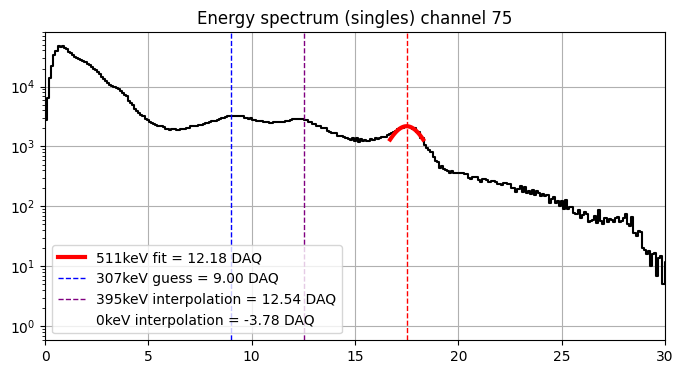

In [11]:

plt.figure(figsize = (8, 4))
plt.step(bincenters, hist, where = 'mid', color = 'black')
pfitcenter = 18
fb = [int(pfitcenter * 10 - 10), int(pfitcenter * 10 + 10)]
fit, pcov = curve_fit(gaussianbg, bincenters[fb[0]:fb[1]], hist[fb[0]:fb[1]], p0 = [50, bincenters[fb[0] + np.argmax(hist[fb[0]:fb[1]])], 1, hist[fb[0]]])
plottingbounds = [fit[1] - 0.8, fit[1] + 0.8]
plt.plot(np.linspace(plottingbounds[0], plottingbounds[1], 100), gaussianbg(np.linspace(plottingbounds[0], plottingbounds[1], 100), *fit), color = 'red', linewidth = 3, label = f'511keV fit = {popt[1]:.2f} DAQ')
plt.axvline(fit[1], color = 'red', linestyle = '--', linewidth = 1)
guess = 9
plt.axvline(guess, color = 'blue', linestyle = '--', linewidth = 1, label = f'307keV guess = {guess:.2f} DAQ')
e307 = guess
diff = fit[1] - e307
pedestal = fit[1] - diff * (511 / 204)
e395 = fit[1] - diff * (119 / 204)
plt.axvline(e395, color = 'purple', linestyle = '--', linewidth = 1, label = f'395keV interpolation = {e395:.2f} DAQ')
plt.axvline(pedestal, alpha = 0, label = f'0keV interpolation = {pedestal:.2f} DAQ')
plt.yscale('log')
plt.xlim(0, 30)
plt.legend(loc = 'lower left')
plt.grid()
plt.title(f'Energy spectrum (singles) channel {id}')
plt.show()

In [209]:
idlist = list(range(0, 1024)) + list(range(4096, 5120)) + list(range(8192, 9216)) + list(range(131072, 132096)) + list(range(135168, 136192)) + list(range(139264, 140288))
idlistL = list(range(131072, 132096)) + list(range(135168, 136192)) + list(range(139264, 140288))

In [218]:
id = np.random.choice(idlistL)
bins = np.linspace(0, 40, 400)
bincenters = (bins[:-1] + bins[1:]) / 2
hist, _= np.histogram([], bins = bins)
for i in tqdm(range(0, num_rows, 1000000)):
    chunk = data[i:i+1000000]
    chunk = chunk[chunk['id'] == id]
    hist += np.histogram(chunk['energy'], bins = bins)[0]
print(id, np.sum(hist))
if id > 100000:
    photopeakRh = np.genfromtxt(photopeak_dirh, dtype = np.float32)[3072:]
    photopeakRm = np.genfromtxt(photopeak_dirm, dtype = np.float32)[3072:]
    id = id - 131072
else:
    photopeakRh = np.genfromtxt(photopeak_dirh, dtype = np.float32)[:3072]
    photopeakRm = np.genfromtxt(photopeak_dirm, dtype = np.float32)[:3072]



100%|██████████| 1992/1992 [00:47<00:00, 42.03it/s]

135247 240931


11.979949874686717
[ 4.56343674e+02  1.21829417e+01 -1.91088525e-01  2.58979856e+03] [2820 2746 2636 2672 2645 2565 2528 2546 2489 2463 2553 2566 2528 2591
 2534 2518 2654 2630 2718 2850]


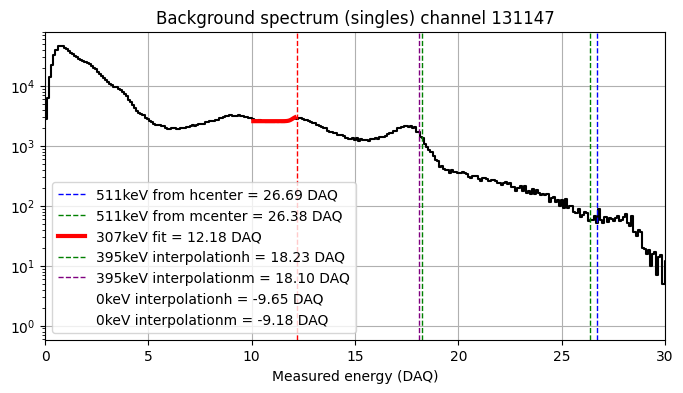

In [10]:

plt.figure(figsize = (8, 4))
plt.step(bincenters, hist, where = 'mid', color = 'black')
photopeakh = (photopeakRh[id % 3072][0] + photopeakRh[id % 3072][1]) / 2
plt.axvline(photopeakh, color = 'blue', linestyle = '--', linewidth = 1, label = f'511keV from hcenter = {photopeakh:.2f} DAQ')
photopeakm = (photopeakRm[id % 3072][0] + photopeakRm[id % 3072][1]) / 2
plt.axvline(photopeakm, color = 'green', linestyle = '--', linewidth = 1, label = f'511keV from mcenter = {photopeakm:.2f} DAQ')
plt.yscale('log')
plt.grid()
fitcenter = 11
fb = [int(fitcenter * 10 - 10), int(fitcenter * 10 + 10)] 
print(bincenters[fb[0] + np.argmax(hist[fb[0]:fb[1]])])
popt, pcov = curve_fit(gaussianbg, bincenters[fb[0]:fb[1]], hist[fb[0]:fb[1]], p0 = [300, bincenters[fb[0] + np.argmax(hist[fb[0]:fb[1]])], 1, hist[fb[0]]])
print(popt, hist[fb[0]:fb[1]])
plt.plot(np.linspace(bincenters[fb[0]], bincenters[fb[1]], 100), gaussianbg(np.linspace(bincenters[fb[0]], bincenters[fb[1]], 100), *popt), color = 'red', linewidth = 3, label = f'307keV fit = {popt[1]:.2f} DAQ')
plt.axvline(popt[1], color = 'red', linestyle = '--', linewidth = 1)
e307 = popt[1]
diffh = photopeakh - e307
pedestalh = photopeakh - diffh * (511 / 204)
diffm = photopeakm - e307
pedestalm = photopeakm - diffm * (511 / 204)
e395h = photopeakh - diffh * (119 / 204)
e395m = photopeakm - diffm * (119 / 204)
plt.axvline(e395h, color = 'green', linestyle = '--', linewidth = 1, label = f'395keV interpolationh = {e395h:.2f} DAQ')
plt.axvline(e395m, color = 'purple', linestyle = '--', linewidth = 1, label = f'395keV interpolationm = {e395m:.2f} DAQ')
plt.plot([0], [0], alpha = 0, label = f'0keV interpolationh = {pedestalh:.2f} DAQ')
plt.plot([0], [0], alpha = 0, label = f'0keV interpolationm = {pedestalm:.2f} DAQ')

plt.xlim(0, 30)
plt.xlabel('Measured energy (DAQ)')
plt.legend(loc = 'lower left')
plt.title(f'Background spectrum (singles) channel {id + 131072}')
plt.show()